In [ ]:
%pip install puremacro


# Frontera DSGE: política discrecional, DSGE-VAR y noticias anticipadas

**¿Cómo equilibran los bancos centrales estabilización y credibilidad cuando reoptimizan en cada período, cómo disciplinar los vectores autorregresivos con distribuciones a priori de equilibrio general microfundamentadas y cómo reaccionan los agentes a las noticias antes de que cambien los fundamentos?**

Los modelos DSGE linealizados suelen suponer una regla fija para el instrumento (una regla de Taylor) y choques que llegan por sorpresa. Este cuaderno desarrolla tres extensiones:

1. **Discreción frente a compromiso** (Oudiz & Sachs 1985; Clarida, Galí & Gertler 1999; Dennis 2007):
   Una autoridad que no puede comprometer a sus sucesores reoptimiza cada período, tomando como dadas las expectativas privadas. Con una meta de producto superior al potencial ($y^* > 0$), esto genera el **sesgo inflacionario** de Kydland-Prescott / Barro-Gordon y, ante choques de costos, un **sesgo de estabilización**: la discreción no permite prometer la respuesta persistente que el compromiso utiliza para orientar las expectativas.

2. **DSGE-VAR** (Del Negro & Schorfheide 2004):
   Las autocovarianzas teóricas $\Gamma_k(\theta)$ del DSGE centran una distribución a priori conjugada normal-Wishart invertida para un VAR. Un hiperparámetro $\lambda$ determina cuántas observaciones artificiales del DSGE representa la distribución a priori; la log-densidad marginal $\ln p(Y \mid \lambda, \theta)$ a lo largo de $\lambda$ muestra cuánto peso asignan los datos a las restricciones del DSGE.

3. **Choques de noticias (anticipados)** (Beaudry & Portier 2006; Schmitt-Grohé & Uribe 2012):
   Las reformas fiscales, la tecnología y la orientación futura suelen anunciarse antes de entrar en vigor. Los choques anticipados se incorporan mediante una matriz de desplazamiento nilpotente $K_H$: el estado exógeno afectado no cambia antes de la fecha programada, mientras las variables prospectivas reaccionan al anuncio.

También utilizamos el **preprocesador macro de Dynare**, los **diagnósticos de identificación por rango** de Iskrev (2010) y Komunjer & Ng (2011), y el **widget de deslizadores de IRF**, todo en Python puro bajo el contrato de cuatro paquetes de Pyodide. Todos los modelos son calibraciones construidas para el ejemplo y todos los datos son simulados.

## El Método en Matemáticas: Invariantes Estructurales y Fundamentos Recursivos

**1. Discreción Óptima Markov-Perfecta.** La autoridad monetaria minimiza la función de pérdida cuadrática:
$$ \min_{u_t} \mathbb{E}_t \sum_{\tau=0}^\infty \beta^\tau \left[ \pi_{t+\tau}^2 + \lambda_y (y_{t+\tau} - y^*)^2 + \lambda_u u_{t+\tau}^2 \right] $$
sujeta a las restricciones estructurales del sector privado:
$$ A_0 y_t = A_1 y_{t-1} + A_2 \mathbb{E}_t y_{t+1} + B u_t + C \epsilon_t $$
Dado que la autoridad reoptimiza en cada período $t$, las expectativas futuras se forman racionalmente bajo la regla futura $u_{t+1} = -F y_t$. Dennis (2007) y Oudiz & Sachs (1985) demuestran que la función de valor satisface la ecuación matricial de Riccati:
$$ V = Q + F' R F + \beta T' V T $$
donde $T$ es la matriz de transición de lazo cerrado. La iteración de funciones de política produce la matriz de retroalimentación estacionaria $F^*$ y la matriz de continuación semidefinida positiva $V \ge 0$.

**2. Mapeo de Momentos a Priori en DSGE-VAR.** Sean $\Gamma_{YY}(\theta)$ y $\Gamma_{XX}(\theta)$ las matrices de autocovarianza teóricas generadas por el modelo DSGE. Del Negro & Schorfheide (2004) definen la distribución a priori sobre los parámetros del VAR $\Phi$ y la covarianza de perturbaciones $\Sigma$ como:
$$ \Sigma \mid \theta \sim \mathcal{IW}\left( \lambda T \Gamma_{YY}^*(\theta), \lambda T - k \right), \quad \Phi \mid \Sigma, \theta \sim \mathcal{N}\left( \Phi^*(\theta), \Sigma \otimes (\lambda T \Gamma_{XX}^*(\theta))^{-1} \right) $$
La verosimilitud marginal de los datos $p(Y \mid \lambda, \theta)$ se evalúa analíticamente en forma cerrada:
$$ \ln p(Y \mid \lambda, \theta) = -\frac{n T}{2} \ln \pi + \sum_{i=1}^n \left[ \ln \Gamma\left(\frac{(1+\lambda)T - k + 1 - i}{2}\right) - \ln \Gamma\left(\frac{\lambda T - k + 1 - i}{2}\right) \right] - \frac{n}{2}\ln|\lambda T \Gamma_{XX}^*| + \dots $$

**3. Aumentación Nilpotente del Espacio de Estados para Noticias.** Una perturbación anticipada con horizonte $k$ cumple:
$$ \epsilon_t = \eta_t^0 + \sum_{l=1}^H \eta_{t-l}^l $$
Definiendo el vector complementario de noticias $V_t = [\eta_t^1, \eta_t^2, \dots, \eta_t^H]'$, la ley de movimiento es:
$$ V_t = K_H V_{t-1} + \xi_t, \quad K_H = \begin{bmatrix} 0 & 1 & 0 & \dots & 0 \\ 0 & 0 & 1 & \dots & 0 \\ \vdots & \vdots & \vdots & \ddots & 1 \\ 0 & 0 & 0 & \dots & 0 \end{bmatrix} $$
Puesto que $K_H^H = \mathbf{0}$, todos los autovalores de $K_H$ son cero ($\rho(K_H) = 0$); la ampliación agrega únicamente raíces estables y no modifica el conteo de Blanchard-Kahn del modelo original.

## Intuición

**Intuición.** Tres problemas prospectivos recorren este cuaderno: credibilidad, especificación incorrecta e información que llega antes de que cambien los fundamentos.

Primero, un banco central sin un mecanismo de compromiso no puede prometer de forma creíble que mantendrá una política restrictiva cuando el choque se haya disipado: el público sabe que reoptimizará cada período. Si la meta de producto supera el potencial, el público espera mayor inflación promedio (*sesgo inflacionario*), y el banco pierde la capacidad de usar promesas de política futura ante un choque de costos (*sesgo de estabilización*).

Segundo, un DSGE con parametrización rígida es, como máximo, una aproximación al proceso generador de datos. El DSGE-VAR utiliza las covarianzas del modelo como distribución a priori para un VAR no restringido; la verosimilitud marginal a lo largo de $\lambda$ indica cuántas «observaciones del modelo» están dispuestos a aceptar los datos.

Tercero, los hogares y las empresas prospectivos reaccionan a anuncios creíbles. Una mejora tecnológica anunciada para dentro de cuatro trimestres modifica hoy las tasas reales esperadas, el producto y la inflación, aunque la productividad todavía no haya cambiado.

In [1]:
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configuración editorial y paleta de visualización
_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Garantizar ejecución limpia sin bloqueo en modo script
if not hasattr(sys, "ps1") and "IPython" not in sys.modules:
    plt.show = lambda *args, **kwargs: None

from puremacro.dsge.macro import preprocess_macro
from puremacro.dsge.dynare import build_dynare
from puremacro.dsge.widgets import interactive_irf
from puremacro.dsge.identification import identification
from puremacro.dsge.policy import optimal_policy
from puremacro.dsge.dsge_var import estimate_dsge_var
from puremacro.dsge.news import news_irf, decompose_news

print("Módulo Frontera DSGE de puremacro cargado exitosamente.")

Módulo Frontera DSGE de puremacro cargado exitosamente.


## 1. Preprocesador Macro de Dynare y Deslizadores Interactivos (Fase A)

En investigaciones aplicadas, los modelos incorporan con frecuencia banderas condicionales (indexación de precios activa/inactiva, número de sectores o variantes de la regla de Taylor). El preprocesador de `puremacro` interpreta de forma nativa directivas `@#define`, `@#if/@#else`, `@#for` e interpolaciones `@{EXPR}` de Dynare antes de compilar al espacio de estados.

A continuación, especificamos un modelo neokeynesiano canónico de 3 ecuaciones con indexación retroactiva condicional de precios $\gamma_p \in [0, 1]$ y perturbación autorregresiva de costos $u_t$:

In [2]:
NK_MACRO_SRC = """
@#define USE_INDEXATION = 1

var y pi r u;
varexo eps_u;

parameters beta sigma kappa phi_pi phi_y rho_u gamma_p;
beta    = 0.99;   // Quarterly discount factor
sigma   = 1.00;   // Inverse of the intertemporal elasticity of substitution
kappa   = 0.50;   // Slope of NK Phillips Curve
phi_pi  = 1.50;   // Taylor rule inflation coefficient
phi_y   = 0.50;   // Taylor rule output gap coefficient
rho_u   = 0.60;   // Persistence of cost-push shock
gamma_p = 0.35;   // Degree of backward price indexation

model;
  // 1. Dynamic IS Curve
  y = y(+1) - (1/sigma)*(r - pi(+1));

@#if USE_INDEXATION
  // 2. Hybrid New Keynesian Phillips Curve with backward indexation
  pi = (beta / (1 + beta * gamma_p)) * pi(+1) + (gamma_p / (1 + beta * gamma_p)) * pi(-1) + kappa * y + u;
@#else
  // 2. Pure Forward-Looking New Keynesian Phillips Curve
  pi = beta * pi(+1) + kappa * y + u;
@#endif

  // 3. Monetary Policy Taylor Rule
  r = phi_pi * pi + phi_y * y;

  // 4. Cost-push shock process
  u = rho_u * u(-1) + eps_u;
end;

shocks;
  var eps_u; stderr 0.01;
end;
"""

# Expand macro processor directives
expanded_mod = preprocess_macro(NK_MACRO_SRC)
model_nk = build_dynare(expanded_mod)

# Blanchard-Kahn: as many stable generalized eigenvalues as predetermined states
n_stable = int(np.sum(np.abs(model_nk.eigenvalues) < 1.0))

print("--- Model Specification & Macro Expansion ---")
print(f"Endogenous variables : {list(model_nk.variables)}")
print(f"Predetermined states : {list(model_nk.states)}")
print(f"Exogenous shocks     : {list(model_nk.shocks)}")
print(f"Indexation included  : {'pi(-1)' in expanded_mod}")
print(f"Stable roots         : {n_stable} (predetermined states: {model_nk.n_states}); determinate: {model_nk.is_determinate}")

assert "pi" in model_nk.states, "Backward indexation should make pi a predetermined state"
assert model_nk.n_states == 2  # [pi, u]
assert model_nk.is_determinate and n_stable == model_nk.n_states

--- Model Specification & Macro Expansion ---
Endogenous variables : ['y', 'pi', 'r', 'u']
Predetermined states : ['pi', 'u']
Exogenous shocks     : ['eps_u']
Indexation included  : True
Stable roots         : 2 (predetermined states: 2); determinate: True


### Deslizadores de parámetros y resoluciones QZ rápidas

`interactive_irf` crea un widget con deslizadores usando únicamente Matplotlib. Cada movimiento resuelve de nuevo el modelo mediante la descomposición de Schur generalizada (QZ) y actualiza las respuestas impulso. Para un modelo pequeño la resolución requiere unos milisegundos; la latencia exacta depende del equipo.

--- Desempeño del deslizador interactivo ---
Active parameters : ['phi_pi', 'kappa']
Live latency      : 2 ms (depende del equipo)
Updated phi_pi    : 2.25


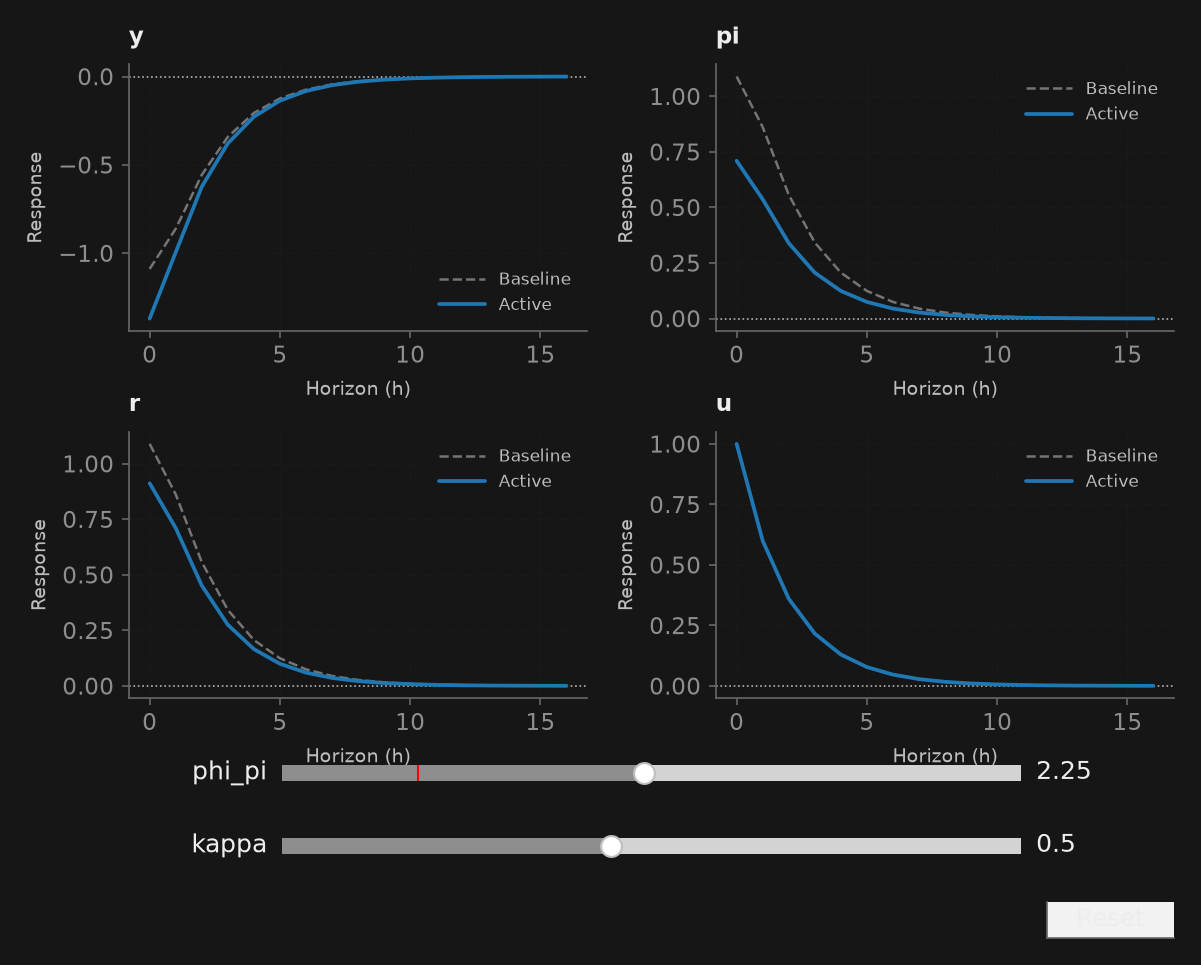

In [3]:
widget = interactive_irf(
    model_nk,
    parameters=["phi_pi", "kappa"],
    param_bounds={"phi_pi": (1.05, 3.5), "kappa": (0.1, 1.0)},
    horizon=16,
)

# Test instantaneous programmatic parameter update (mimicking slider drag)
widget.set_value("phi_pi", 2.25)

print("--- Desempeño del deslizador interactivo ---")
print(f"Active parameters : {list(widget.get_values().keys())}")
print(f"Live latency      : {widget.last_latency_ms:.0f} ms (depende del equipo)")
print(f"Updated phi_pi    : {widget.get_values()['phi_pi']:.2f}")

### Identificación formal de parámetros por rango (Iskrev 2010; Komunjer & Ng 2011)

Antes de optimizar la política o estimar bayesianamente, es necesario verificar la identificación local de los parámetros estructurales. Evaluamos los jacobianos de solución $J_1$ y momentos $J_2$ de Iskrev (2010), junto con los rangos de la función de transferencia $J_H$ y de la densidad espectral $J_S$ de Komunjer & Ng (2011). Las cuatro variables ($y, \pi, r, u$) se consideran observadas y los jacobianos se evalúan en la calibración.

In [4]:
ident_res = identification(model_nk, lags=1)
print(ident_res.summary())

# Diagnóstico de rangos
print(f"Rango de Solución J1 : {ident_res.j1_rank} / {ident_res.n_params}")
print(f"Rango de Momentos J2 : {ident_res.j2_rank} / {ident_res.n_params}")
print(f"Rango Transferencia JH: {ident_res.jh_rank} / {ident_res.n_params}")

PARAMETER IDENTIFICATION ANALYSIS (Iskrev 2010 / Komunjer-Ng 2011)
Overall status         : UNIDENTIFIED (RANK DEFICIENT)
Parameters evaluated   : 7
Observables (varobs)   : y, pi, r, u
Autocovariance lags    : 1
Frequency grid points  : 16
J1 (Solution) rank     : 5 / 7 (DEFICIENT by 2)
J2 (Moments) rank      : 5 / 7 (DEFICIENT by 2)
JH (Transfer) rank     : 5 / 7 (DEFICIENT by 2)
JS (Spectrum) rank     : 5 / 7 (DEFICIENT by 2)

RANK CRITERIA SCORECARD
------------------------------------------------------------------------
                    criterion  rank  total  deficiency  condition_number          status
J1       J1 (Iskrev Solution)     5      7           2               inf  DEFICIENT by 2
J2   J2 (Iskrev Moments, p=1)     5      7           2               inf  DEFICIENT by 2
JH  JH (Komunjer-Ng Transfer)     5      7           2               inf  DEFICIENT by 2
JS  JS (Komunjer-Ng Spectrum)     5      7           2               inf  DEFICIENT by 2

J1 NULL SPACE PARAMETER

El modelo **no** está identificado en esta calibración: todos los criterios tienen rango 5 de 7. La primera dirección nula aumenta conjuntamente $\phi_\pi$ y $\phi_y$. La siguiente celda muestra por qué: con $\sigma = 1$ y $\phi_\pi - \phi_y = 1$, la trayectoria $y_t = -\pi_t$ satisface exactamente la curva IS, de modo que la regla de Taylor solo distingue $(\phi_\pi - \phi_y)\,\pi_t$. Verificamos que $y_t + \pi_t$ sea cero en la respuesta al choque de costos y repetimos el análisis con $\phi_y = 0.25$, que rompe esta coincidencia particular.

In [5]:
irf_u = model_nk.irf("eps_u", horizon=12)
gap_y_pi = float(np.max(np.abs(irf_u["y"] + irf_u["pi"])))

model_nk_alt = build_dynare(preprocess_macro(NK_MACRO_SRC.replace("phi_y   = 0.50;", "phi_y   = 0.25;")))
ident_alt = identification(model_nk_alt, lags=1)

print(f"max |y_t + pi_t| along the cost-push IRF : {gap_y_pi:.1e}")
print(f"J2 rank at phi_y = 0.50                  : {ident_res.j2_rank} / {ident_res.n_params}")
print(f"J2 rank at phi_y = 0.25                  : {ident_alt.j2_rank} / {ident_alt.n_params}")
print(f"Remaining J2 null direction at 0.25      : {ident_alt.j2_null_combinations[0]}")

assert gap_y_pi < 1e-10, "y = -pi must hold exactly when sigma = 1 and phi_pi - phi_y = 1"
assert ident_res.j2_rank == ident_res.n_params - 2
assert ident_alt.j2_rank == ident_res.j2_rank + 1

max |y_t + pi_t| along the cost-push IRF : 2.2e-16
J2 rank at phi_y = 0.50                  : 5 / 7
J2 rank at phi_y = 0.25                  : 6 / 7
Remaining J2 null direction at 0.25      : 0.9560 * beta + 0.2293 * kappa + 0.1829 * gamma_p = 0


## 2. Política monetaria óptima: discreción frente a compromiso

Comparamos la **política discrecional Markov-perfecta**, consistente en el tiempo (Dennis 2007), con el referente de **compromiso**: el plan de Ramsey iniciado en el estado estacionario, cuya ley de movimiento corresponde a la perspectiva atemporal.

El banco central minimiza la función de pérdida cuadrática:
$$ \mathcal{L}_t = \mathbb{E}_t \sum_{\tau=0}^\infty \beta^\tau \left[ \pi_{t+\tau}^2 + 0.25 (y_{t+\tau} - y^*)^2 \right] $$
donde $y^* = 0.05$ representa una meta positiva de brecha del producto de 5% (por ejemplo, para contrarrestar distorsiones de competencia monopolística).

In [6]:
target_output = 0.05
loss_weights = {"pi": 1.0, "y": 0.25}

# Resolución de política discrecional con comparación automatizada de compromiso
policy_res = optimal_policy(
    model_nk,
    loss=loss_weights,
    rule="discretion",
    instruments="r",
    y_star=target_output,
    compare_commitment=True,
    tol=1e-9,
    max_iter=2000,
)

print(policy_res.summary())

OPTIMAL POLICY REGIME: DISCRETION (DENNIS 2007)
Policymaker discount (beta): 0.9900
Expected unconditional loss : 1.547488e-04
Conditional loss (from s.s.): 1.536502e-04
Policy instruments          : r
Target variables            : pi (w=1.0), y (w=0.25)
Convergence status          : Converged in 14 iterations (diff=8.09e-10)
Inflation bias (E[pi^disc] - E[pi^comm]): 2.475248e-02
Stabilization bias (Loss^disc - Loss^comm, unconditional): 3.712375e-05
Riccati value matrix (norm) : 5.784186e-01

POLICY REACTION FUNCTIONS (Coefficients on States)
------------------------------------------------------------------------
     y        pi         u    r
r -0.0  0.269297  0.500897 -0.0


### Cuantificación del bienestar: sesgos de inflación y estabilización

1. **Sesgo inflacionario**: como $y^* > 0$, la autoridad discrecional tiene incentivos para generar inflación inesperada y elevar el producto. Quienes fijan precios lo anticipan, por lo que aumenta la inflación promedio sin una ganancia sistemática de producto ($E[\pi^{\text{disc}}] > 0$). Con compromiso, la inflación promedio es cero.
2. **Sesgo de estabilización**: después de un choque de costos, un banco central con compromiso promete mantener el producto por debajo del potencial incluso cuando el choque se disipe. La promesa reduce la inflación esperada y suaviza la disyuntiva actual. Bajo discreción esa promesa no es creíble. Las pérdidas siguientes son esperanzas incondicionales (`loss_criterion="unconditional"`); `stabilization_bias` es su diferencia y toma NaN si no se calculó una solución con compromiso.

In [7]:
loss_gain_pct = 100.0 * policy_res.stabilization_bias / policy_res.loss

print("--- Desglose de sesgos de bienestar ---")
print(f"Output Gap Target (y*)                : {target_output:+.4f}")
print(f"Inflation Bias (E[pi] gap)            : {policy_res.inflation_bias:+.6f}")
print(f"Expected Loss under Discretion        : {policy_res.loss:.4e}")
print(f"Expected Loss under Commitment        : {policy_res.commitment_result.loss:.4e}")
print(f"Stabilization Bias (Excess Loss)      : {policy_res.stabilization_bias:.4e}")
print(f"Pérdida ahorrada con compromiso (% de discreción) : {loss_gain_pct:.1f}%")

# Analytical assertions
assert policy_res.converged, "Riccati policy iteration must converge"
assert policy_res.inflation_bias > 0.0, "Positive y* must generate positive inflation bias"
assert policy_res.stabilization_bias > 0.0, "At beta = 0.99 discretion also loses on average (unconditional loss)"

--- Desglose de sesgos de bienestar ---
Output Gap Target (y*)                : +0.0500
Inflation Bias (E[pi] gap)            : +0.024752
Expected Loss under Discretion        : 1.5475e-04
Expected Loss under Commitment        : 1.1763e-04
Stabilization Bias (Excess Loss)      : 3.7124e-05
Pérdida ahorrada con compromiso (% de discreción) : 24.0%


Graficamos las respuestas impulso a un choque de costos de una desviación estándar ($\sigma_u = 1\%$) bajo discreción y compromiso, calculadas a partir de los dos modelos resueltos con sus reglas de política.

Impact output gap (pp)  : discretion -1.495, commitment -1.188
Impact inflation (pp)   : discretion +0.542, commitment +0.441
Lowest inflation under commitment (pp): -0.100


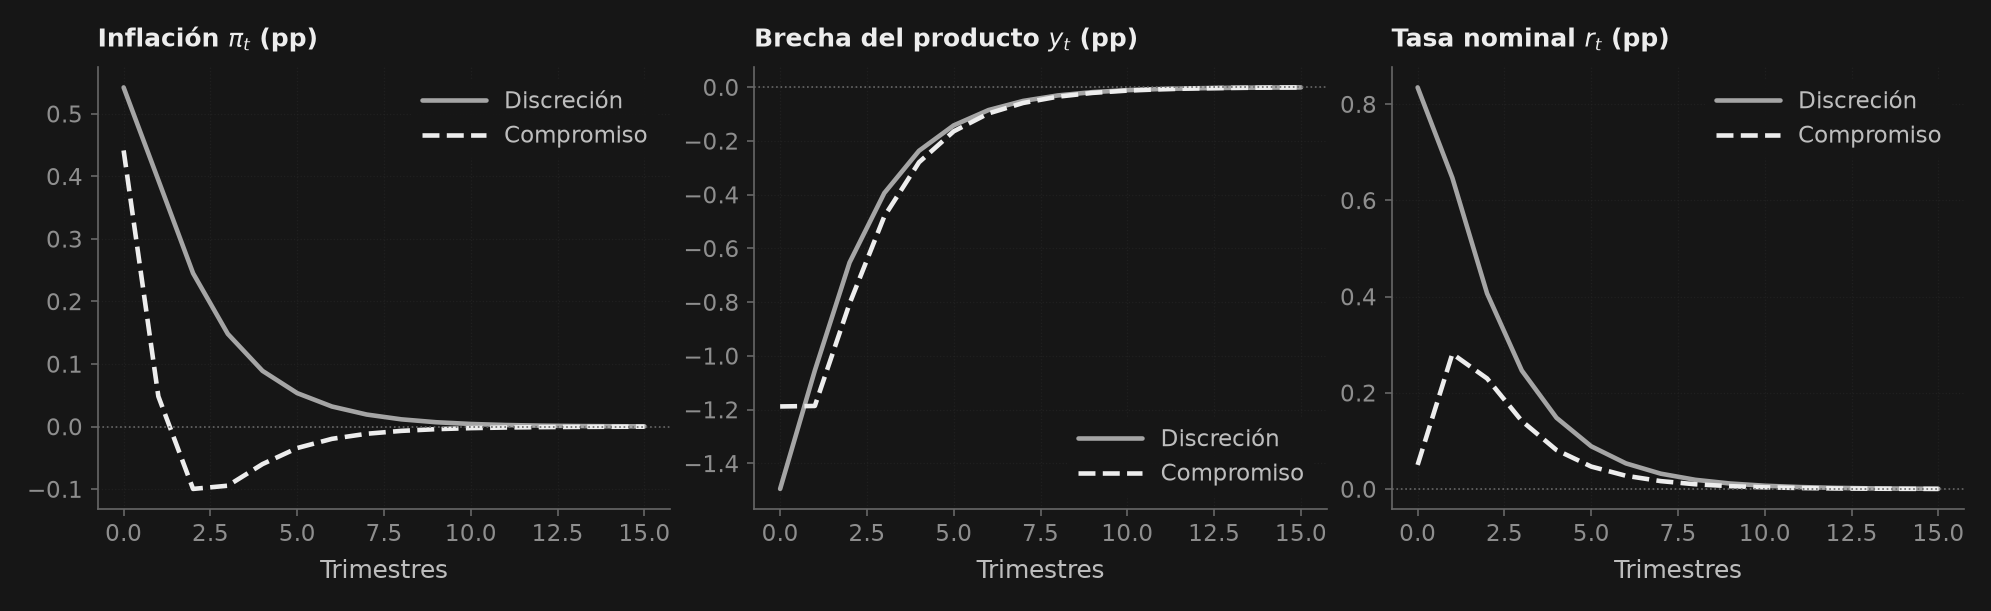

In [8]:
H = 16
sd_u = float(np.sqrt(model_nk._shock_cov[0, 0]))  # stderr of eps_u from the shocks block
irf_disc = policy_res.linear_model.irf("eps_u", horizon=H - 1) * sd_u * 100.0
irf_comm = policy_res.commitment_result.linear_model.irf("eps_u", horizon=H - 1) * sd_u * 100.0

y0_disc, y0_comm = float(irf_disc["y"].iloc[0]), float(irf_comm["y"].iloc[0])
pi0_disc, pi0_comm = float(irf_disc["pi"].iloc[0]), float(irf_comm["pi"].iloc[0])
pi_min_comm = float(irf_comm["pi"].min())
print(f"Impact output gap (pp)  : discretion {y0_disc:+.3f}, commitment {y0_comm:+.3f}")
print(f"Impact inflation (pp)   : discretion {pi0_disc:+.3f}, commitment {pi0_comm:+.3f}")
print(f"Lowest inflation under commitment (pp): {pi_min_comm:+.3f}")
assert y0_disc < y0_comm < 0.0, "commitment dampens the impact recession"
assert pi_min_comm < 0.0 < float(irf_disc["pi"].min()), "only commitment undershoots inflation"

fig, axes = _nbstyle.figura(1, 3, figsize=(13, 3.8))
for ax, var, title in zip(axes, ["pi", "y", "r"],
                          [r"Inflación $\pi_t$ (pp)", r"Brecha del producto $y_t$ (pp)", r"Tasa nominal $r_t$ (pp)"]):
    ax.plot(np.arange(H), irf_disc[var].to_numpy(), label="Discreción", color=_nbstyle.S2["color"], lw=2.2)
    ax.plot(np.arange(H), irf_comm[var].to_numpy(), label="Compromiso", color=_nbstyle.S1["color"], lw=2.2, linestyle="--")
    ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, linestyle=":")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Trimestres")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend()

## 3. Modelos híbridos DSGE-VAR (Del Negro & Schorfheide 2004)

Conectamos ahora el modelo DSGE teórico con un VAR(1) no restringido para las series macroeconómicas $Y_t = [y_t, \pi_t, r_t]'$.

Especificamos un modelo neokeynesiano con tres choques: tecnología ($a_t$), costos ($u_t$) y política monetaria ($r_t$). Simulamos $T=250$ trimestres de datos sintéticos **a partir de este mismo modelo** y evaluamos la log-densidad marginal a lo largo de la rejilla de peso a priori $\lambda \in [0.25, 5.0]$:

In [9]:
NK_DSGE_VAR_MOD = """
var y pi r a u;
varexo eps_a eps_u eps_r;

parameters beta sigma kappa phi_pi phi_y rho_a rho_u;
beta   = 0.99;
sigma  = 1.00;
kappa  = 0.25;
phi_pi = 1.50;
phi_y  = 0.25;
rho_a  = 0.80;
rho_u  = 0.50;

model;
  y = y(+1) - (1/sigma)*(r - pi(+1)) + (a(+1) - a);
  pi = beta*pi(+1) + kappa*y + u;
  r = phi_pi*pi + phi_y*y + eps_r;
  a = rho_a*a(-1) + eps_a;
  u = rho_u*u(-1) + eps_u;
end;

shocks;
  var eps_a; stderr 0.010;
  var eps_u; stderr 0.008;
  var eps_r; stderr 0.004;
end;
"""

m_dsge_var = build_dynare(NK_DSGE_VAR_MOD)
sim_data = m_dsge_var.simulate(250, seed=123)[["y", "pi", "r"]]

print("--- Datos Macroeconómicos Simulados ---")
print(sim_data.describe().round(4))

--- Datos Macroeconómicos Simulados ---
              y        pi         r
count  250.0000  250.0000  250.0000
mean    -0.0011    0.0009    0.0013
std      0.0156    0.0113    0.0139
min     -0.0347   -0.0296   -0.0373
25%     -0.0128   -0.0070   -0.0077
50%     -0.0022    0.0024    0.0021
75%      0.0097    0.0089    0.0116
max      0.0391    0.0262    0.0339


Estimamos el DSGE-VAR(1) para valores candidatos del peso a priori $\lambda$. Cuando $\lambda \to \lambda_{\min}$, el estimador se aproxima al VAR no restringido por MCO; cuando $\lambda \to \infty$, impone estrictamente las restricciones teóricas del DSGE:

In [10]:
lambda_grid = [0.25, 0.50, 0.75, 1.00, 1.50, 2.00, 3.00, 4.00, 5.00]

res_dvar = estimate_dsge_var(
    model=m_dsge_var,
    data=sim_data,
    p=1,
    lamb="optimal",
    lambda_grid=lambda_grid,
)

print(res_dvar.summary())

DSGE-VAR Estimation (Del Negro & Schorfheide 2004)
Sample size (T):           249 (Effective after 1 lags)
Observables (n):           3 (y, pi, r)
Structural shocks:         3 (eps_a, eps_u, eps_r)
VAR lag order (p):         1
Identification:            dsge
------------------------------------------------------------------------------
Prior weight (lambda):     5.0000
Admissibility bound (min): 0.0281 = (k + n) / T
Optimal lambda (hat):      5.0000
Log Marginal Data Density: 2829.4901
Estimated VAR Coefficients (tilde{Phi}):
            y      pi       r
const -0.0001  0.0001  0.0001
L1.y   0.5105  0.0846  0.2531
L1.pi -0.4424  0.3791  0.4707
L1.r   0.3935  0.1984  0.3866
------------------------------------------------------------------------------
Posterior Innovation Covariance (tilde{Sigma}):
           y        pi         r
y   0.000173 -0.000118 -0.000144
pi -0.000118  0.000095  0.000111
r  -0.000144  0.000111  0.000141
-----------------------------------------------------------

### Perfil de optimización de la densidad marginal

Graficamos la log-densidad marginal $\ln p(Y \mid \lambda, \theta)$ como función del peso a priori $\lambda$. Un máximo interior indicaría que algunas, pero no todas, las restricciones del DSGE ayudan; un máximo en el mayor $\lambda$ indica que los datos favorecen tanto peso del modelo como permite la rejilla.

 lambda  log_mdd
   0.25  2820.55
   0.50  2824.40
   0.75  2826.07
   1.00  2827.00
   1.50  2828.01
   2.00  2828.53
   3.00  2829.07
   4.00  2829.33
   5.00  2829.49
Optimal prior weight hat(lambda) : 5.0000 (mayor valor de la rejilla: 5.00)
Log MDD at optimum               : 2829.49
Log-MDD aumenta en cada paso de la rejilla : True


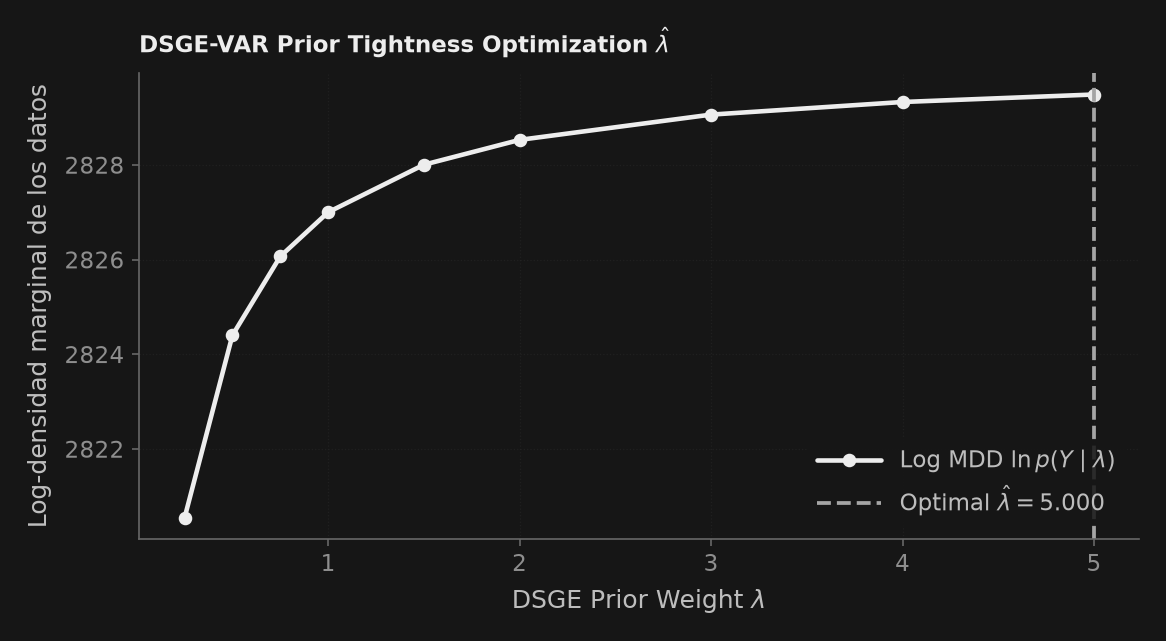

In [11]:
grid_df = res_dvar.log_mdd_grid
mdd_steps = np.diff(grid_df["log_mdd"].to_numpy())

fig, ax = _nbstyle.figura(1, 1, figsize=(7.5, 4.0))
ax.plot(grid_df["lambda"], grid_df["log_mdd"], marker="o", color=_nbstyle.S1["color"], lw=2.2, label=r"Log MDD $\ln p(Y \mid \lambda)$")
ax.axvline(res_dvar.hat_lambda, color=_nbstyle.S2["color"], linestyle="--", lw=1.8, label=rf"Optimal $\hat{{\lambda}} = {res_dvar.hat_lambda:.3f}$")
ax.set_title(r"DSGE-VAR Prior Tightness Optimization $\hat{\lambda}$", fontsize=11, fontweight="bold")
ax.set_xlabel(r"DSGE Prior Weight $\lambda$")
ax.set_ylabel("Log-densidad marginal de los datos")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="lower right")

print(grid_df.round(2).to_string(index=False))
print(f"Optimal prior weight hat(lambda) : {res_dvar.hat_lambda:.4f} (mayor valor de la rejilla: {max(lambda_grid):.2f})")
print(f"Log MDD at optimum               : {res_dvar.log_mdd:.2f}")
print(f"Log-MDD aumenta en cada paso de la rejilla : {bool(np.all(mdd_steps > 0))}")

## 4. Motor de choques anticipados y de noticias (Beaudry & Portier 2006)

¿Cómo reaccionan las economías ante anuncios creíbles de innovaciones futuras?

Examinamos un choque tecnológico anticipado anunciado en $t=0$ con $k=4$ trimestres de adelanto: hoy se conoce que el proceso tecnológico $a_t$ recibirá una innovación unitaria en $t=4$.

La construcción garantiza tres propiedades que verificamos numéricamente:
1. **Estado sin revisión anticipada**: el estado tecnológico exógeno no puede moverse antes de la fecha prevista ($a_t = 0$ para $t < 4$).
2. **Salto de las variables prospectivas**: al formar expectativas racionales, los hogares y las empresas modifican producto, inflación y tasa de política en $t=0$, cuando reciben el anuncio.
3. **Materialización exacta**: en $t=4$ se realiza exactamente la innovación del choque ($a_4 = 1.0$).

In [12]:
# Solve News IRF for technology shock with 4-quarter anticipation lead
news_res = news_irf(m_dsge_var, shock="eps_a", lead=4, horizon=16)

print(news_res.summary())

# Extract impulse responses
irf_df = news_res.irf
a_path = irf_df["a"].to_numpy()
y_path = irf_df["y"].to_numpy()
pi_path = irf_df["pi"].to_numpy()
r_path = irf_df["r"].to_numpy()

# Mathematical property checks
max_pre_realiz_a = np.max(np.abs(a_path[:4]))
impact_y = y_path[0]
impact_pi = pi_path[0]
realiz_a = a_path[4]

print("\n--- Empirical Verification of News Properties ---")
print(f"1. Max physical state revision for t < 4 : {max_pre_realiz_a:.1e} (0 salvo redondeo)")
print(f"2. Output gap jump at announcement (t=0) : {impact_y:+.4f}")
print(f"3. Inflation jump at announcement (t=0)  : {impact_pi:+.4f}")
print(f"4. Exact realization at date t=4        : {realiz_a:+.4f} (innovación unitaria)")

assert np.isclose(max_pre_realiz_a, 0.0, atol=1e-12), "Predetermined state cannot change before realization"
assert not np.isclose(impact_pi, 0.0, atol=1e-4), "Forward-looking controls must jump at announcement"
assert np.isclose(realiz_a, 1.0, atol=1e-6), "Shock must materialize at scheduled horizon"

News Shock IRF Summary: shock='eps_a', lead=4, horizon=16, size=1.0
------------------------------------------------------------------------------
Variable     Impact (t=0)   Pre-realiz     Realiz (t=k)   Peak Dev       Peak t  
------------------------------------------------------------------------------
y                  0.0983        0.5756       -0.1549        0.5756  3       
pi                 0.1271       -0.0404       -0.1862       -0.1862  4       
r                  0.2153        0.0833       -0.3179       -0.3179  4       
a                  0.0000        0.0000        1.0000        1.0000  4       
u                  0.0000        0.0000        0.0000       -0.0000  1       

--- Empirical Verification of News Properties ---
1. Max physical state revision for t < 4 : 2.3e-16 (0 salvo redondeo)
2. Output gap jump at announcement (t=0) : +0.0983
3. Inflation jump at announcement (t=0)  : +0.1271
4. Exact realization at date t=4        : +1.0000 (innovación unitaria)


Graficamos la trayectoria completa desde el anuncio hasta la materialización y decaimiento:

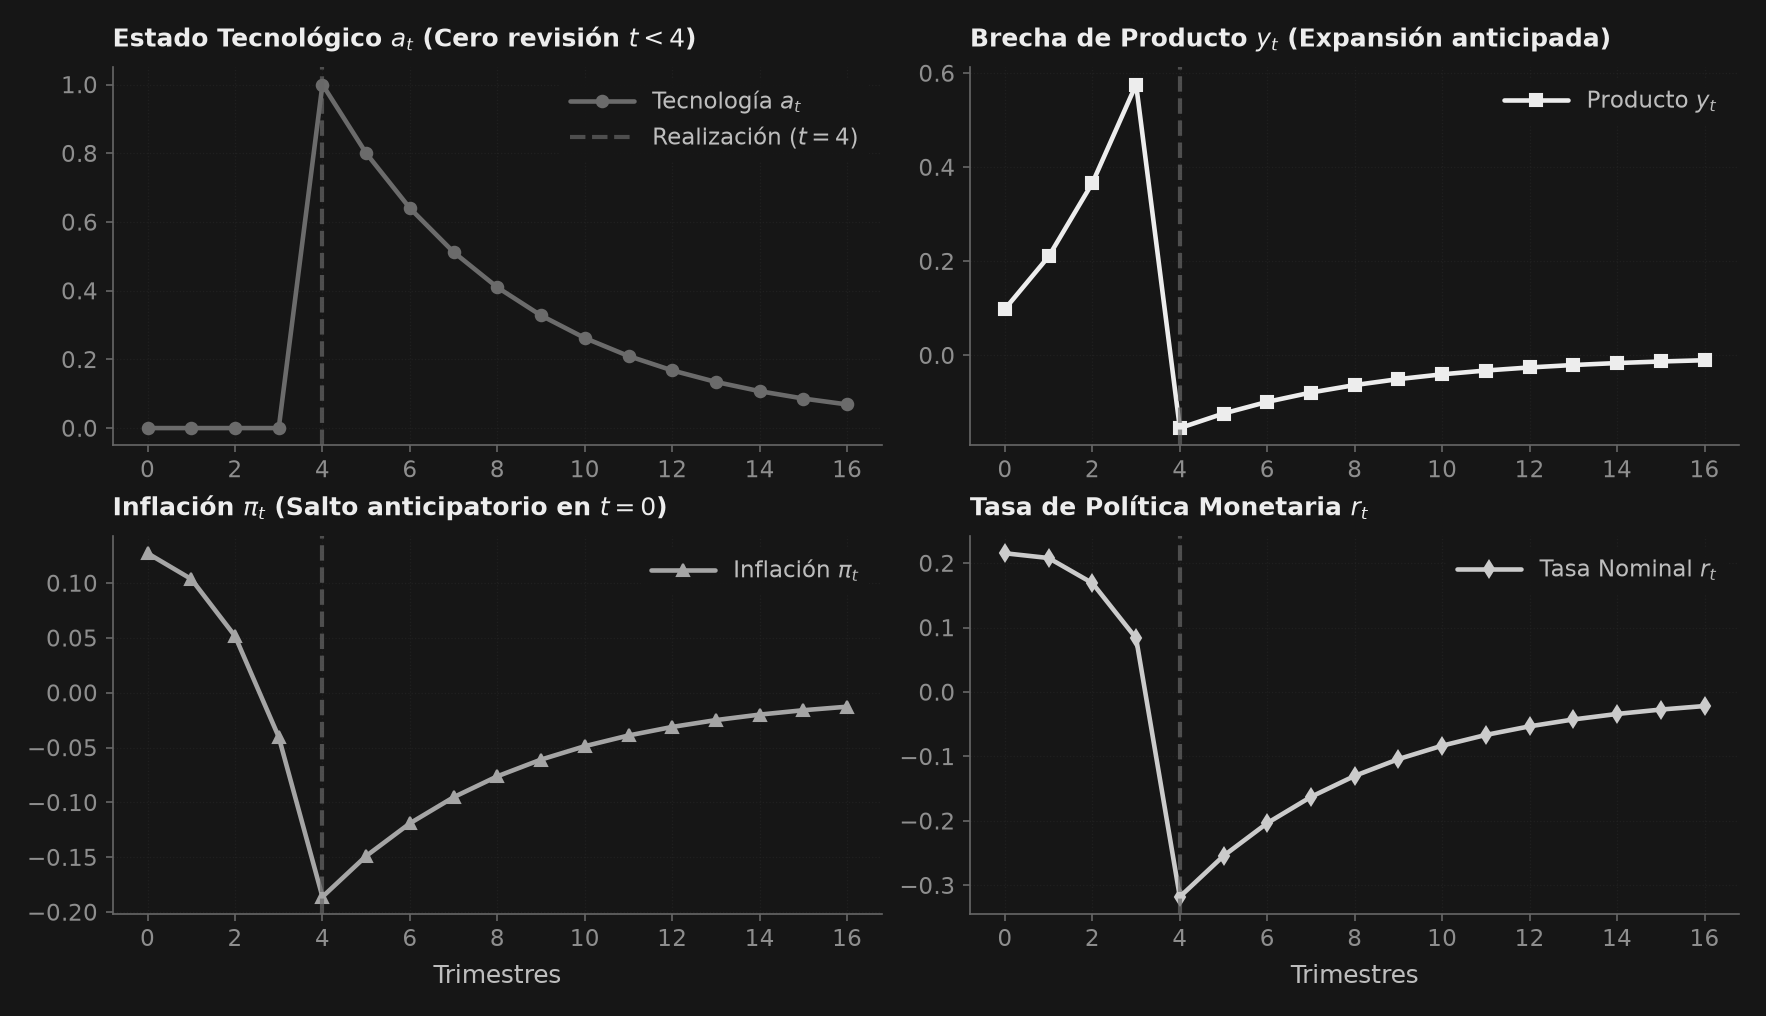

In [13]:
fig, axes = _nbstyle.figura(2, 2, figsize=(11.5, 6.5))

time_axis = np.arange(len(a_path))

# Panel 1: Estado tecnológico
axes[0, 0].plot(time_axis, a_path, color=_nbstyle.S3["color"], lw=2.2, marker="o", label="Tecnología $a_t$")
axes[0, 0].axvline(4, color=_nbstyle.SPINE, linestyle="--", alpha=0.7, label="Realización ($t=4$)")
axes[0, 0].set_title(r"Estado Tecnológico $a_t$ (Cero revisión $t < 4$)", fontweight="bold")
axes[0, 0].grid(True, linestyle=":", alpha=0.6)
axes[0, 0].legend()

# Panel 2: Brecha de producto
axes[0, 1].plot(time_axis, y_path, color=_nbstyle.S1["color"], lw=2.2, marker="s", label="Producto $y_t$")
axes[0, 1].axvline(4, color=_nbstyle.SPINE, linestyle="--", alpha=0.7)
axes[0, 1].set_title(r"Brecha de Producto $y_t$ (Expansión anticipada)", fontweight="bold")
axes[0, 1].grid(True, linestyle=":", alpha=0.6)
axes[0, 1].legend()

# Panel 3: Inflación
axes[1, 0].plot(time_axis, pi_path, color=_nbstyle.S2["color"], lw=2.2, marker="^", label=r"Inflación $\pi_t$")
axes[1, 0].axvline(4, color=_nbstyle.SPINE, linestyle="--", alpha=0.7)
axes[1, 0].set_title(r"Inflación $\pi_t$ (Salto anticipatorio en $t=0$)", fontweight="bold")
axes[1, 0].set_xlabel("Trimestres")
axes[1, 0].grid(True, linestyle=":", alpha=0.6)
axes[1, 0].legend()

# Panel 4: Tasa de interés
axes[1, 1].plot(time_axis, r_path, color=_nbstyle.S4["color"], lw=2.2, marker="d", label="Tasa Nominal $r_t$")
axes[1, 1].axvline(4, color=_nbstyle.SPINE, linestyle="--", alpha=0.7)
axes[1, 1].set_title(r"Tasa de Política Monetaria $r_t$", fontweight="bold")
axes[1, 1].set_xlabel("Trimestres")
axes[1, 1].grid(True, linestyle=":", alpha=0.6)
axes[1, 1].legend()

### Descomposición de varianza del error de pronóstico: sorpresa y anticipaciones

¿Qué proporción de la varianza del error de pronóstico de cada variable proviene de la sorpresa y de cada anticipación $k \in \{1, 2, 3, 4\}$? `decompose_news` asigna **varianza unitaria de innovación** tanto a la sorpresa como a cada anticipación. Las participaciones describen la propagación de innovaciones del mismo tamaño, no una estimación de la importancia de las noticias en los datos.

In [14]:
decomp = decompose_news(m_dsge_var, shock="eps_a", max_lead=4, horizon=16)

print(decomp.summary())

# Verify row stochasticity: shares must sum to 1.0
fevd_shares = decomp.variance_shares
print("\nVariance Shares at Horizon H=16:")
print(fevd_shares.round(4))

News Shock Variance Decomposition: shock='eps_a', horizon=16, max_lead=4
------------------------------------------------------------------------------
    surprise  news_1  news_2  news_3  news_4  total_news
y     0.0309  0.1844  0.2465  0.2669  0.2714      0.9691
pi    0.1806  0.1836  0.1885  0.2085  0.2387      0.8194
r     0.1703  0.1745  0.1917  0.2178  0.2457      0.8297
a     0.2002  0.2001  0.2001  0.1999  0.1997      0.7998
u     1.0000  0.0000  0.0000  0.0000  0.0000      0.0000

Variance Shares at Horizon H=16:
    surprise  news_1  news_2  news_3  news_4
y     0.0309  0.1844  0.2465  0.2669  0.2714
pi    0.1806  0.1836  0.1885  0.2085  0.2387
r     0.1703  0.1745  0.1917  0.2178  0.2457
a     0.2002  0.2001  0.2001  0.1999  0.1997
u     1.0000  0.0000  0.0000  0.0000  0.0000


## 5. Exportaciones Editoriales para Difusión y Publicación

Exportamos las tablas de comparación de política y descomposición de noticias a formatos LaTeX y Markdown:

In [15]:
print("--- LaTeX Table Export: Policy Comparison ---")
print(policy_res.to_latex())

print("--- Markdown Table Export: News Variance Decomposition ---")
print(decomp.to_markdown())

--- LaTeX Table Export: Policy Comparison ---
\begin{tabular}{lrrrr}
index & y & pi & u & r \\
\hline
r & 0 & 0.269297 & 0.500897 & 0 \\
\end{tabular}
--- Markdown Table Export: News Variance Decomposition ---
| index | surprise |   news_1 |   news_2 |   news_3 |   news_4 |
|-------|----------|----------|----------|----------|----------|
|     y | 0.030854 |  0.18436 | 0.246506 | 0.266917 | 0.271362 |
|    pi | 0.180607 | 0.183617 | 0.188534 |  0.20855 | 0.238692 |
|     r | 0.170293 | 0.174458 | 0.191705 | 0.217806 | 0.245738 |
|     a | 0.200199 | 0.200142 | 0.200052 | 0.199913 | 0.199695 |
|     u |        1 |        0 |        0 |        0 |        0 |


## Lectura de los resultados

**Lectura de los resultados.**
1. **Macroprocesamiento e identificación.** El preprocesador conserva la rama de indexación, por lo que `pi` pasa a ser un estado predeterminado; hay dos raíces estables para dos estados y el modelo es determinado. **No** está identificado en esta calibración: $J_1$, $J_2$, $J_H$ y $J_S$ tienen rango 5 de 7. Una dirección nula aumenta conjuntamente $\phi_\pi$ y $\phi_y$: con $\sigma = 1$ y $\phi_\pi - \phi_y = 1$, $y_t = -\pi_t$ es una relación exacta de equilibrio (el máximo $|y_t + \pi_t|$ en la respuesta al choque de costos es inferior a 1e-12), y la regla solo revela $\phi_\pi - \phi_y$. Con $\phi_y = 0.25$, el rango de $J_2$ sube a 6 de 7; la dirección nula restante combina $\beta$, $\kappa$ y $\gamma_p$, parámetros de la curva de Phillips que un único choque no permite separar. Superar esta verificación es necesario antes de estimar; no superarla, como aquí, implica que la verosimilitud es plana en esas direcciones.
2. **Discreción frente a compromiso.** Con $y^* = 0.05$, la discreción genera un sesgo inflacionario de +0.024752, mientras el compromiso mantiene la inflación promedio en cero. La pérdida incondicional es 1.5475e-04 bajo discreción y 1.1763e-04 bajo compromiso: el compromiso ahorra 24.0% de la pérdida discrecional (sesgo de estabilización 3.7124e-05). Las respuestas impulso muestran el mecanismo: ante un choque de costos de una desviación estándar, el producto cae 1.495 puntos porcentuales al impacto bajo discreción y 1.188 bajo compromiso. El compromiso mantiene el producto por debajo del potencial durante más tiempo y permite que la inflación caiga bajo cero (mínimo de -0.100 puntos porcentuales), en vez de converger desde valores positivos.
3. **DSGE-VAR.** La log-densidad marginal aumenta en todos los pasos de la rejilla, de 2820.55 con $\lambda = 0.25$ a 2829.49 con $\lambda = 5$; por tanto, $\hat{\lambda} = 5.0$ está en el extremo superior. Es una solución de esquina, no un máximo interior: los datos se simularon con el mismo modelo que centra la distribución a priori, de modo que más peso del modelo resulta favorable. Con datos reales o un modelo a priori mal especificado (véase el ejercicio intermedio), el perfil puede alcanzar su máximo con un $\lambda$ pequeño.
4. **Choques de noticias.** Ante noticias tecnológicas con cuatro trimestres de adelanto, el estado exógeno permanece en cero antes de $t = 4$ (desviación máxima inferior a 1e-12) y luego se materializa exactamente ($a_4 = 1.0000$). Producto (+0.0983), inflación (+0.1271) y tasa de política (+0.2153) reaccionan al anuncio; el producto sigue aumentando hasta un máximo de +0.5756 en el trimestre 3, justo antes de la innovación. Con varianzas de innovación iguales, las noticias explican 96.9% de la varianza del error de pronóstico del producto a 16 trimestres y 81.9% de la inflación; estas participaciones reflejan el supuesto de varianza unitaria, no datos observados.

## Tu turno

La siguiente celda resuelve de nuevo la discreción para otra meta de producto y las noticias para otro adelanto. Verifica dos propiedades que deben cumplirse para cualquier elección admisible: el sesgo inflacionario es lineal en $y^*$ (el problema es lineal-cuadrático), y la respuesta del producto al anuncio satisface la curva IS iterada hacia adelante, $y_0 = -\sum_{t\ge 0}(r_t - \pi_{t+1}) - a_0$. La regla de Taylor descompone la tasa real acumulada en $(\phi_\pi - 1)\sum_t \pi_t + \phi_y \sum_t y_t + \pi_0$.

**Consignas.**
1. *Básica — origen del sesgo inflacionario.* Reconstruya el modelo de la sección 1 sin indexación (cambie `@#define USE_INDEXATION = 1` por `= 0`). A partir de la condición de primer orden discrecional $\kappa \pi + \lambda_y (y - y^*) = 0$ y de la curva de Phillips estacionaria $(1 - \beta)\pi = \kappa y$, derive la inflación promedio $\bar{\pi}(\kappa)$ en forma cerrada y compárela con `optimal_policy(..., rule="discretion", y_star=target_output).inflation_bias` (deben coincidir a 1e-9). Encuentre analíticamente el $\kappa^*$ que maximiza $\bar{\pi}$ y compruébelo: reconstruya el modelo para $\kappa = 0.01, 0.015, \dots, 0.20$ y verifique que el máximo de la biblioteca esté a no más de un paso de la rejilla de su $\kappa^*$. ¿Por qué desaparece el sesgo cuando $\kappa \to 0$ si $\beta < 1$, por qué disminuye con $\kappa$ grande y qué ocurriría con $\beta = 1$?
2. *Intermedia — ¿detecta $\hat{\lambda}$ la especificación incorrecta?* Simule $T = 250$ trimestres (semilla 123) con una copia de `NK_DSGE_VAR_MOD` que suavice la tasa, `r = 0.8*r(-1) + 0.2*(phi_pi*pi + phi_y*y) + eps_r;`, y reestime el DSGE-VAR manteniendo la distribución a priori centrada en el modelo con regla estática. Verifique que $\hat{\lambda}$ caiga al extremo inferior de la búsqueda mientras el caso correctamente especificado permanezca en el superior, y que el perfil log-MDD mal especificado disminuya en cada paso. ¿Por qué pueden compararse las formas de los perfiles, pero no sus niveles? Repita con las semillas 1 y 2.
3. *Avanzada — cambio de signo del efecto del anuncio.* Ejecute `lead_yt = 2, 4, 8` en la celda siguiente y registre $y_0$. Use la descomposición impresa de la tasa real acumulada para explicar por qué el producto aumenta ante anuncios cercanos, pero cae con $L = 8$. ¿Qué partes de la trayectoria representan relajación prometida y cuáles endurecimiento anticipado? ¿Entre qué dos adelantos cambia el signo?

In [16]:
# ← change this: output target y*, any value in [0.01, 0.10]
target_output_yt = 0.08
# ← change this: news lead in quarters, any integer in [1, 12]
lead_yt = 2
assert 0.01 <= target_output_yt <= 0.10 and lead_yt in range(1, 13)

# 1. Re-solve optimal policy under custom output gap target
policy_yt = optimal_policy(
    model_nk,
    loss=loss_weights,
    rule="discretion",
    instruments="r",
    y_star=target_output_yt,
    compare_commitment=True,
    tol=1e-9,
)

# 2. Re-solve news IRF under custom anticipation horizon (long horizon so the sums converge)
irf_yt = news_irf(m_dsge_var, shock="eps_a", lead=lead_yt, horizon=200).irf
y_n, pi_n, r_n, a_n = (irf_yt[k].to_numpy() for k in ("y", "pi", "r", "a"))
cum_rr = float(np.sum(r_n[:-1] - pi_n[1:]))
split = ((1.5 - 1.0) * pi_n.sum(), 0.25 * y_n.sum(), pi_n[0])  # phi_pi = 1.5, phi_y = 0.25 in NK_DSGE_VAR_MOD

print(f"Optimal Policy (y* = {target_output_yt:+.2f}):")
print(f"  Inflation bias : {policy_yt.inflation_bias:+.6f} (Baseline y*=0.05: {policy_res.inflation_bias:+.6f})")
print(f"  Bias per unit of y*: {policy_yt.inflation_bias / target_output_yt:.6f} (baseline {policy_res.inflation_bias / target_output:.6f})")
print(f"News Shock (Lead = {lead_yt} quarters):")
print(f"  Output at announcement y0      : {y_n[0]:+.4f}")
print(f"  Minus cumulative real rate     : {-cum_rr:+.4f}")
print(f"  Split (phi_pi-1)*sum(pi), phi_y*sum(y), pi0 : {split[0]:+.4f}, {split[1]:+.4f}, {split[2]:+.4f}")
print(f"  State at realization (t={lead_yt})  : {a_n[lead_yt]:+.4f}")

# Downstream automated assertions
assert policy_yt.converged
assert abs(policy_yt.inflation_bias / target_output_yt - policy_res.inflation_bias / target_output) < 1e-9, "bias must be linear in y*"
assert abs(y_n[0] + cum_rr + a_n[0]) < 1e-8, "IS curve iterated forward"
assert abs(cum_rr - sum(split)) < 1e-8, "Taylor-rule split of the cumulative real rate"
assert np.isclose(a_n[lead_yt], 1.0, atol=1e-6) and np.max(np.abs(a_n[:lead_yt])) < 1e-12

Optimal Policy (y* = +0.08):
  Inflation bias : +0.039604 (Baseline y*=0.05: +0.024752)
  Bias per unit of y*: 0.495050 (baseline 0.495050)
News Shock (Lead = 2 quarters):
  Output at announcement y0      : +0.3663
  Minus cumulative real rate     : +0.3663
  Split (phi_pi-1)*sum(pi), phi_y*sum(y), pi0 : -0.4598, +0.0419, +0.0516
  State at realization (t=2)  : +1.0000


## ¿Qué tan exhaustivo es esto?

`puremacro.dsge` integra modelos estructurales con expectativas racionales en Python puro:
- `optimal_policy`: Resuelve la política discrecional Markov-perfecta (Dennis 2007; Oudiz & Sachs 1985) mediante iteración matricial de Riccati y la compara con compromiso desde el estado estacionario (Clarida, Galí & Gertler 1999), cuantificando sesgos de inflación y estabilización. El cuaderno 66 contrasta estos solvers con las soluciones cerradas de Clarida, Galí & Gertler (1999).
- `estimate_dsge_var`: Implementa DSGE-VAR($\lambda$) de Del Negro & Schorfheide (2004), vinculando momentos analíticos entre ecuaciones con distribuciones a priori Wishart invertidas para pruebas de especificación del modelo.
- `news_irf` y `decompose_news`: Incorporan estados mediante matrices compañeras nilpotentes para noticias anticipadas (Beaudry & Portier 2006; Schmitt-Grohé & Uribe 2012) y descomponen varianza entre noticias y sorpresas con varianzas de innovación iguales.
- `preprocess_macro`: Preprocesador macro de Dynare en Python puro que resuelve `@#define`, `@#for`, `@#if` e interpolaciones antes de compilar el AST.
- `identification`: Calcula los criterios de identificación por rango de Iskrev (2010) y Komunjer & Ng (2011) sobre jacobianos dinámicos, momentos de autocovarianza y funciones de transferencia espectral.